In [2]:
import os

print(os.listdir())

['.config', 'IMDb Movies India.csv', 'sample_data']


<>:86: SyntaxWarning: invalid escape sequence '\d'
<>:86: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7499/4262670311.py:86: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d+)')


Dataset Loaded Successfully!

First 5 Rows:

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2 

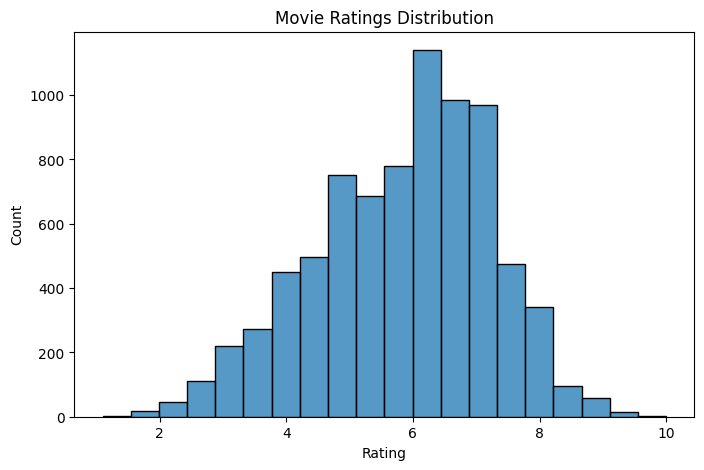

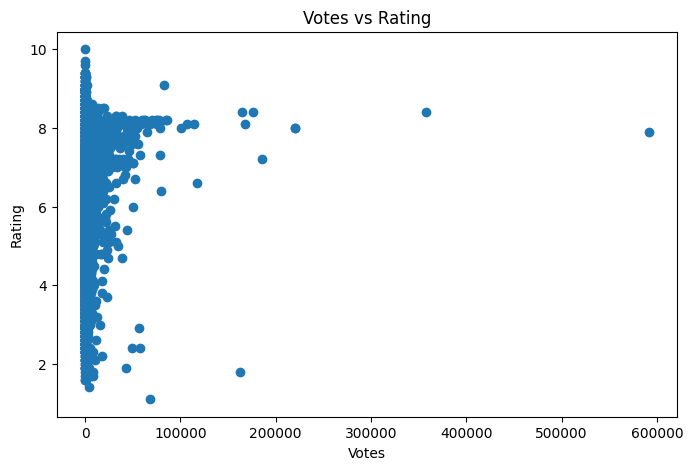

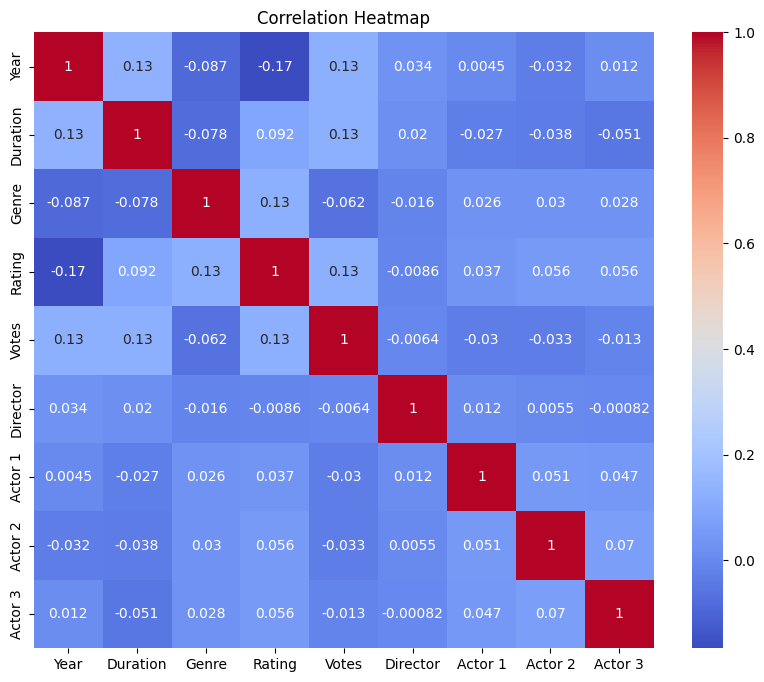


Training Data Shape: (6335, 8)
Testing Data Shape: (1584, 8)

Model Training Completed!

Predictions Completed!

MODEL PERFORMANCE

Mean Absolute Error: 0.8266565656565656
Mean Squared Error: 1.2023287765151516
Root Mean Squared Error: 1.0965075360047243
R2 Score: 0.3532894499567599


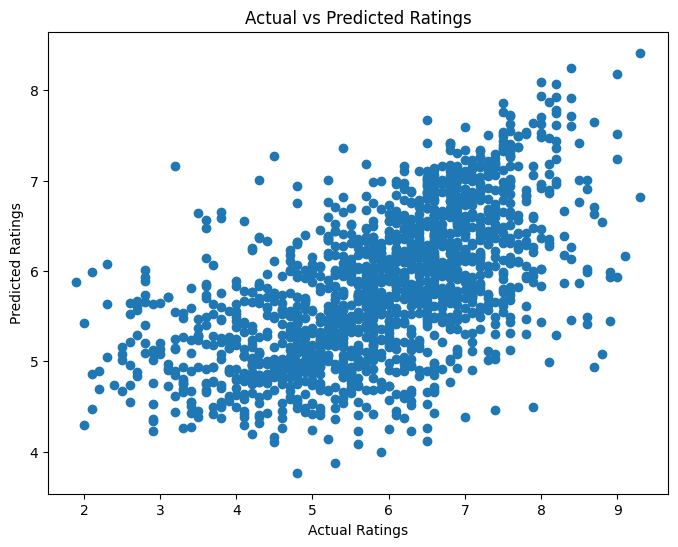


Feature Importance:

    Feature  Importance
3     Votes    0.214247
0      Year    0.201217
1     Genre    0.127738
7   Actor 3    0.100640
6   Actor 2    0.097522
5   Actor 1    0.095916
4  Director    0.085030
2  Duration    0.077691

Predicted Movie Rating:
5.120999999999999

Model Saved Successfully!

Movie Rating Prediction Project Completed Successfully!


In [3]:
# ==========================================
# MOVIE RATING PREDICTION PROJECT
# DATASET: IMDb Movies India.csv
# ==========================================

# ==========================================
# STEP 1 — IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')


# ==========================================
# STEP 2 — LOAD DATASET
# ==========================================

# Upload the file manually in Colab first:
# Left Sidebar → Files → Upload → IMDb Movies India.csv

df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

print("Dataset Loaded Successfully!\n")

print("First 5 Rows:\n")
print(df.head())


# ==========================================
# STEP 3 — DATASET INFORMATION
# ==========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())


# ==========================================
# STEP 4 — DATA CLEANING
# ==========================================

# Remove rows with missing rating
df.dropna(subset=['Rating'], inplace=True)

# Fill missing values in categorical columns
df['Genre'].fillna('Unknown', inplace=True)
df['Director'].fillna('Unknown', inplace=True)
df['Actor 1'].fillna('Unknown', inplace=True)
df['Actor 2'].fillna('Unknown', inplace=True)
df['Actor 3'].fillna('Unknown', inplace=True)

# Fill missing duration
df['Duration'].fillna('0 min', inplace=True)

# Fill missing votes
df['Votes'].fillna('0', inplace=True)


# ==========================================
# STEP 5 — DATA PREPROCESSING
# ==========================================

# Clean Year column
df['Year'] = df['Year'].str.extract('(\d+)')

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['Year'].fillna(df['Year'].median(), inplace=True)


# Clean Duration column
df['Duration'] = df['Duration'].str.replace(' min', '')

df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

df['Duration'].fillna(df['Duration'].median(), inplace=True)


# Clean Votes column
df['Votes'] = df['Votes'].astype(str)

df['Votes'] = df['Votes'].str.replace(',', '')

df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

df['Votes'].fillna(df['Votes'].median(), inplace=True)


# ==========================================
# STEP 6 — ENCODE CATEGORICAL COLUMNS
# ==========================================

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

df['Director'] = le.fit_transform(df['Director'])

df['Actor 1'] = le.fit_transform(df['Actor 1'])

df['Actor 2'] = le.fit_transform(df['Actor 2'])

df['Actor 3'] = le.fit_transform(df['Actor 3'])


# ==========================================
# STEP 7 — FINAL DATASET
# ==========================================

print("\nProcessed Dataset:\n")
print(df.head())


# ==========================================
# STEP 8 — DATA VISUALIZATION
# ==========================================

# Ratings Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Rating'], bins=20)

plt.title('Movie Ratings Distribution')

plt.xlabel('Rating')

plt.ylabel('Count')

plt.show()


# Votes vs Rating

plt.figure(figsize=(8,5))

plt.scatter(df['Votes'], df['Rating'])

plt.title('Votes vs Rating')

plt.xlabel('Votes')

plt.ylabel('Rating')

plt.show()


# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()


# ==========================================
# STEP 9 — SELECT FEATURES AND TARGET
# ==========================================

X = df[[
    'Year',
    'Genre',
    'Duration',
    'Votes',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]]

y = df['Rating']


# ==========================================
# STEP 10 — TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ==========================================
# STEP 11 — TRAIN MACHINE LEARNING MODEL
# ==========================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# ==========================================
# STEP 12 — MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

print("\nPredictions Completed!")


# ==========================================
# STEP 13 — MODEL EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE\n")

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)


# ==========================================
# STEP 14 — ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()


# ==========================================
# STEP 15 — FEATURE IMPORTANCE
# ==========================================

importance = model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:\n")

print(feature_df)


# ==========================================
# STEP 16 — CUSTOM PREDICTION
# ==========================================

# Sample Input Format:
# [Year, Genre, Duration, Votes, Director, Actor1, Actor2, Actor3]

sample_movie = [[
    2020,
    5,
    120,
    50000,
    100,
    200,
    300,
    400
]]

predicted_rating = model.predict(sample_movie)

print("\nPredicted Movie Rating:")

print(predicted_rating[0])


# ==========================================
# STEP 17 — SAVE MODEL
# ==========================================

import joblib

joblib.dump(model, 'movie_rating_prediction_model.pkl')

print("\nModel Saved Successfully!")


# ==========================================
# PROJECT COMPLETED
# ==========================================

print("\nMovie Rating Prediction Project Completed Successfully!")